# Anchor-free検出器

Faster R-CNNやSSD、YOLOv2以降は、あらかじめ決めたスケール・アスペクト比のアンカーボックスを画像上の各位置に敷き詰め、そこからのオフセットを回帰することで検出を行っていた（アンカーベース）。この設計には次のような課題がある。

- アンカーのスケール・アスペクト比・数・IoU閾値など、データセットごとにチューニングが必要なハイパーパラメータが多い
- 1枚の画像に対して数万〜十万オーダーのアンカーを生成するため、その大半（背景）が正例・負例の判定にしか使われず計算・メモリの無駄が大きい
- IoU閾値によるアンカー↔正解ボックスのマッチングが離散的で、学習が不安定になりやすい

**Anchor-free（アンカーフリー）検出器** は、アンカーを使わず、特徴マップ上の各位置（ピクセル）から直接ボックスを予測する。代表的な手法として **FCOS** を中心に扱い、関連するCornerNet・CenterNetにも触れる。

## FCOS（Fully Convolutional One-Stage Object Detection）

[Tian et al. (2019), FCOS: Fully Convolutional One-Stage Object Detection](https://arxiv.org/abs/1904.01355)

### 各位置からの直接回帰

FCOSは、セマンティックセグメンテーションのように特徴マップ上の各位置（画素）ごとに予測を行う。ある位置 $(x, y)$ が正解ボックス $B = (x_0, y_0, x_1, y_1)$ の内部にあるとき、その位置から見たボックスの4辺までの距離 $(l, t, r, b)$ を回帰する。

$$
l = x - x_0,\quad t = y - y_0,\quad r = x_1 - x,\quad b = y_1 - y
$$

推論時はこの4値から直接ボックス座標を復元できるため、アンカーのオフセットのような中間表現を経由しない。分類ヘッドはクラスごとの2値分類（この位置が特定クラスの物体の内部かどうか）を行う。

### あいまいさ（ambiguity）の解消：マルチレベル予測

1つの位置が複数の正解ボックスの内部に重なって属してしまう場合（ambiguous sample）、どのボックスを回帰すべきか一意に決まらない。FCOSはFPN（Feature Pyramid Network）による複数解像度の特徴マップを使い、各レベルが回帰すべきボックスの大きさの範囲 $(m_{i-1}, m_i)$ をあらかじめ決めておくことで、これを緩和する（小さい物体は高解像度・浅い層、大きい物体は低解像度・深い層が担当）。

### Centerness

アンカーフリーの回帰は、物体の中心から離れた（＝ボックスの端に近い）位置でも予測を行うため、低品質な（ずれた）ボックスが多く生成されやすい。FCOSはこれを抑えるため、各位置について **centerness** という補助スコアを別途予測する。

$$
\mathrm{centerness}^* = \sqrt{\frac{\min(l, r)}{\max(l, r)} \times \frac{\min(t, b)}{\max(t, b)}}
$$

物体の中心に近いほど1に近づき、端に近づくほど0に近づく。推論時はこのcenterness予測値を分類スコアに掛け合わせてランキングに使うことで、中心から離れた低品質なボックスをNMSの前段階で自然に抑制できる。

### 損失関数

$$
L(\{p_{x,y}\}, \{t_{x,y}\}) =
\frac{1}{N_{\mathrm{pos}}} \sum_{x,y} L_{\mathrm{cls}}(p_{x,y}, c^*_{x,y})
+ \frac{\lambda}{N_{\mathrm{pos}}} \sum_{x,y} \mathbb{1}_{\{c^*_{x,y} > 0\}}\, L_{\mathrm{reg}}(t_{x,y}, t^*_{x,y})
$$

- 分類損失 $L_{\mathrm{cls}}$ にはFocal Loss（クラス不均衡に強い、[RetinaNet](https://arxiv.org/abs/1708.02002) で提案）
- 回帰損失 $L_{\mathrm{reg}}$ にはIoU損失（後述のGIoUなど、スケールに依存しない指標）
- Centernessはbinary cross entropyで別途学習

### メリット

- アンカーに関するハイパーパラメータ（スケール・アスペクト比・IoU閾値）が不要
- 1画素1候補のためアンカーベースよりも候補数を大幅に削減できる
- Faster R-CNNやRetinaNetと同等以上の精度を、よりシンプルな設計で達成

## 関連手法：キーポイントベースのアンカーフリー検出

FCOSが「各画素からボックスを直接回帰する」アプローチであるのに対し、物体を特徴的な**キーポイント**として検出する系統も存在する。

### CornerNet

[Law & Deng (2018), CornerNet: Detecting Objects as Paired Keypoints](https://arxiv.org/abs/1808.01244)

物体のバウンディングボックスを「左上コーナー」と「右下コーナー」という2つのキーポイントの組として検出する。ヒートマップ回帰でコーナー候補を検出したあと、同じ物体に属するコーナーのペアを対応付けるために **embedding vector**（同一物体のコーナー同士は近く、異なる物体のコーナー同士は遠くなるように学習）を用いる。

### CenterNet

[Zhou et al. (2019), Objects as Points](https://arxiv.org/abs/1904.07850)

物体を「中心点」1点のキーポイントとして検出し、その中心点から幅・高さを直接回帰する。コーナーのペアリングのような対応付け処理が不要になり、CornerNetよりシンプル。NMSなしで（ヒートマップ上の局所最大値を取るだけで）検出結果を得られる設計も特徴。

## 実行例：FCOS による推論

`torchvision` の COCO 事前学習済み FCOS（ResNet-50-FPNバックボーン）でサンプル画像を検出する。

cat


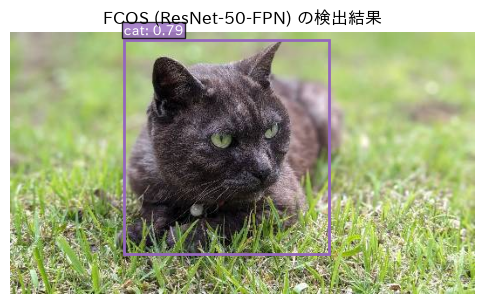

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib_fontja
import torch
from PIL import Image
from torchvision.models.detection import fcos_resnet50_fpn, FCOS_ResNet50_FPN_Weights

weights = FCOS_ResNet50_FPN_Weights.COCO_V1
model = fcos_resnet50_fpn(weights=weights)
model.eval()
categories = weights.meta["categories"]

img = Image.open("../sample_images/cat1.jpg").convert("RGB")
x = weights.transforms()(img)

with torch.no_grad():
    output = model([x])[0]

score_threshold = 0.50
fig, ax = plt.subplots(figsize=[6, 4])
ax.imshow(img)
for box, label, score in zip(output["boxes"], output["labels"], output["scores"]):
    if score < score_threshold:
        continue
    x0, y0, x1, y1 = box.tolist()
    ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="tab:purple", facecolor="none"))
    print(categories[label])
    ax.text(x0, y0 - 5, f"{categories[label]}: {score:.2f}", color="white",
            bbox=dict(facecolor="tab:purple", alpha=0.8, pad=1))
ax.set_title("FCOS (ResNet-50-FPN) の検出結果")
ax.axis("off")
plt.show()

## 参考文献

- Tian, Z. et al. (2019). [FCOS: Fully Convolutional One-Stage Object Detection](https://arxiv.org/abs/1904.01355)
- Lin, T.-Y. et al. (2017). [Focal Loss for Dense Object Detection (RetinaNet)](https://arxiv.org/abs/1708.02002)
- Law, H. & Deng, J. (2018). [CornerNet: Detecting Objects as Paired Keypoints](https://arxiv.org/abs/1808.01244)
- Zhou, X. et al. (2019). [Objects as Points (CenterNet)](https://arxiv.org/abs/1904.07850)
- [torchvision.models.detection.fcos_resnet50_fpn — Torchvision documentation](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.detection.fcos_resnet50_fpn.html)